# Project: Xử lý ảnh cơ bản — Histogram, Convolution, Median/Mean Filter, Thresholding

**Mục tiêu (tóm tắt):**
1. Cho 1 ảnh màu I kích thước n × m, chuyển I → ảnh xám:
   - Vẽ Histogram của I (H1)
   - Tính Histogram cân bằng của I (H2)
   - Hiệu chỉnh thu hẹp H2 trong khoảng [30, 80]

2. Cho 1 ảnh màu I, chuyển I → ảnh xám:
   - Dùng convolution với:
     - Kernel 3×3, padding=1 → I1
     - Kernel 5×5, padding=2 → I2
     - Kernel 7×7, padding=3, stride=2 → I3
   - I4 = median_filter(I3, neighbors=3×3)
   - I5 = median_filter (actually mean) của I1 với neighbors 5×5
   - I6: nếu I4(x,y) > I5(x,y) → I6(x,y)=0 else I6(x,y)=I5(x,y)
     (Nếu kích thước khác nhau → pad để cùng kích thước trước khi so sánh.)



## Chuẩn bị môi trường: 

- Dùng `PIL.Image` để đọc ảnh màu và chuyển sang grayscale (giữ cấu trúc code gốc).
- Dùng `numpy` để xử lý ma trận pixel.
- Dùng `matplotlib` để hiển thị ảnh & histogram.



In [62]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os

In [63]:
imageData = Image.open('./input/data.jpg')

imgGray = imageData.convert('L') # Luminance
imgGray.save('./output/gray_image.jpg')

# imgGray12 = imgGray.resize((12, 12))
matrix = np.array(imgGray, dtype=float)
print(matrix)
np.savetxt("./output/ma_tran_muc_xam.txt", matrix, fmt="%3d", delimiter=" ")

[[255. 255. 255. ...  88.  87.  93.]
 [140. 138. 134. ...  77.  81.  90.]
 [ 34.  32.  28. ... 120. 136. 149.]
 ...
 [217. 192. 178. ... 196. 191. 188.]
 [225. 191. 167. ... 158. 166. 173.]
 [170. 147. 168. ... 179. 170. 152.]]


## Phần 1 — Histogram của ảnh gốc (H1)

**Mục tiêu:** tính histogram H1 (tần suất mức xám r_k), hiển thị histogram dạng tần suất và chuẩn hoá ra xác suất p(r_k).

**Lưu ý biến:**
- `matrix` (n×m): ma trận mức xám (float) từ ảnh.
- `hist` (length 256): số điểm có mức xám = k.
- `p_rk`: xác suất p(r_k) = hist[k] / totalPixels.


In [64]:
totalPixels = 0
hist = {}   
p_rk = {}   

for row in matrix:
    for val in row:
        totalPixels += 1
        hist[val] = hist.get(val, 0) + 1

for k in hist:
    p_rk[k] = hist[k] / totalPixels

# print("Tổng số pixel:", totalPixels)
# for gray in sorted(hist):
#     print(f"{gray:3d}: {hist[gray]}")
    
print("Tổng số mức xám khác nhau:", len(hist))


Tổng số mức xám khác nhau: 256


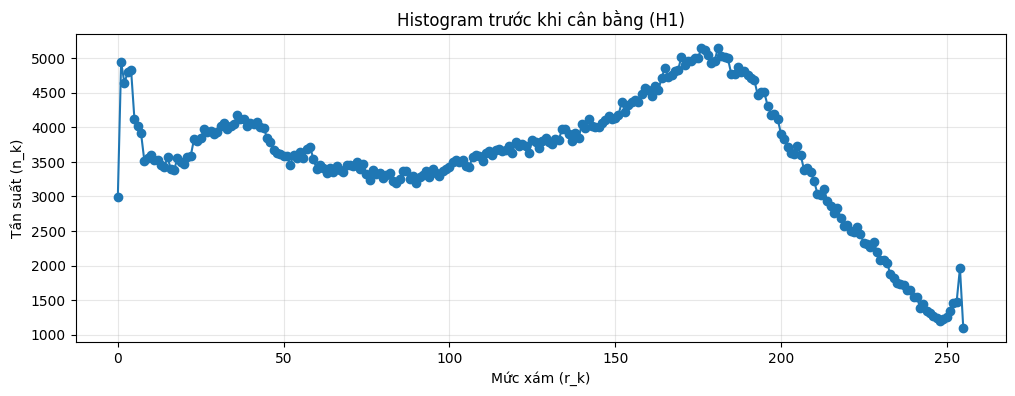

In [65]:
plt.figure(figsize=(12,4))
plt.plot(sorted(p_rk.keys()), [p_rk[k] * totalPixels for k in sorted(p_rk)], marker='o', linestyle='-')
plt.title("Histogram trước khi cân bằng (H1)")
plt.xlabel("Mức xám (r_k)")
plt.ylabel("Tần suất (n_k)")
plt.grid(alpha=0.3)
plt.show()

## 2. Histogram Equalization (H2)

**Mục đích:** tăng độ tương phản bằng cách dùng CDF (Cumulative Distribution Function).

**Thuật toán:**
1. Tính p(r_k).
2. Tính CDF: cdf(r_k) = sum_{i<=k} p(r_i).
3. Mapping: s_k = round((L-1) * cdf(r_k)), L=256.
4. Ảnh cân bằng `matrix_eq` = mapping[matrix].

**Biến chính:**
- `cdf`: mảng 256
- `lut` (lookup table) `mapping`: ánh xạ r → s
- `matrix_eq`: ảnh sau cân bằng (dtype int 0..255)


In [66]:
L = 256 
cdf = {}
sum = 0
mapping = {}
matrixBalanced = []

# Tính hàm phân phối tích lũy (CDF)
for k in sorted(p_rk.keys()):
    sum += p_rk[k]
    cdf[k] = sum

# Xây dựng ánh xạ giá trị mới
for k in sorted(cdf.keys()):
    mapping[k] = round((L - 1) * cdf[k])
    
# Áp dụng mapping cho toàn ảnh
for row in matrix:
    newRow = []
    for val in row:
        newRow.append(mapping[val])
    matrixBalanced.append(newRow)



In [67]:
matrixBalanced = np.array(matrixBalanced)
np.savetxt("./output/ma_tran_sau_can_bang.txt", matrixBalanced, fmt="%3d", delimiter=" ")
print(matrixBalanced)

[[255 255 255 ...  91  90  96]
 [143 141 137 ...  81  85  93]
 [ 37  35  31 ... 122 139 154]
 ...
 [236 210 191 ... 215 209 205]
 [241 209 176 ... 164 175 184]
 [180 151 177 ... 193 180 157]]


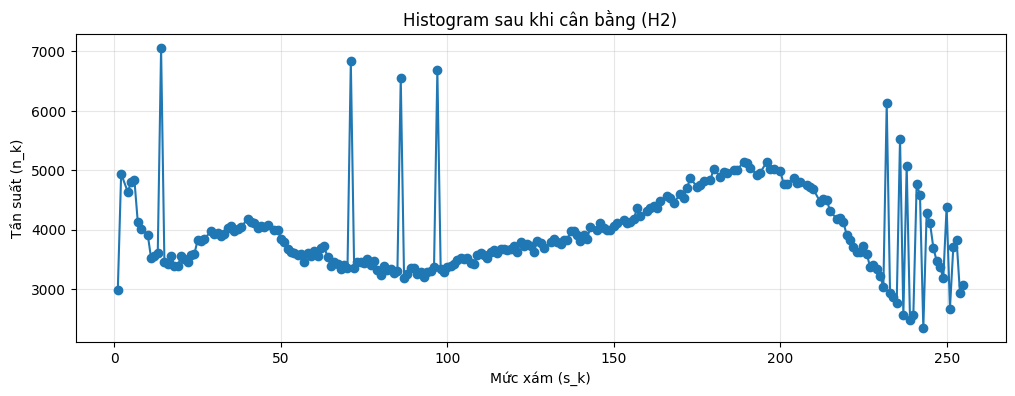

In [68]:
histogramBalanced = {}
for row in matrixBalanced:
    for val in row:
        histogramBalanced[val] = histogramBalanced.get(val, 0) + 1

plt.figure(figsize=(12,4))
plt.plot(sorted(histogramBalanced.keys()), [histogramBalanced[k] for k in sorted(histogramBalanced)], marker='o')
plt.title("Histogram sau khi cân bằng (H2)")
plt.xlabel("Mức xám (s_k)")
plt.ylabel("Tần suất (n_k)")
plt.grid(alpha=0.3)
plt.show()

## 3. Hiệu chỉnh thu hẹp H2 vào khoảng [30, 80]



In [69]:
r_min, r_max =  matrixBalanced.min(), matrixBalanced.max()
s_min, s_max =  30, 80
matrixUpdate = []

#Công thức ánh xạ tuyến tính mức xám
for row in matrixBalanced:
    newRow = []
    for val in row:
        s = ((s_max - s_min) / (r_max - r_min)) * (val - r_min) + s_min
        if s < s_min:
            s = s_min
        elif s > s_max:
            s = s_max
        newRow.append(round(s))
    matrixUpdate.append(newRow)
np.savetxt("./output/ma_tran_sau_thu_hep.txt", matrixUpdate, fmt="%3d", delimiter=" ")

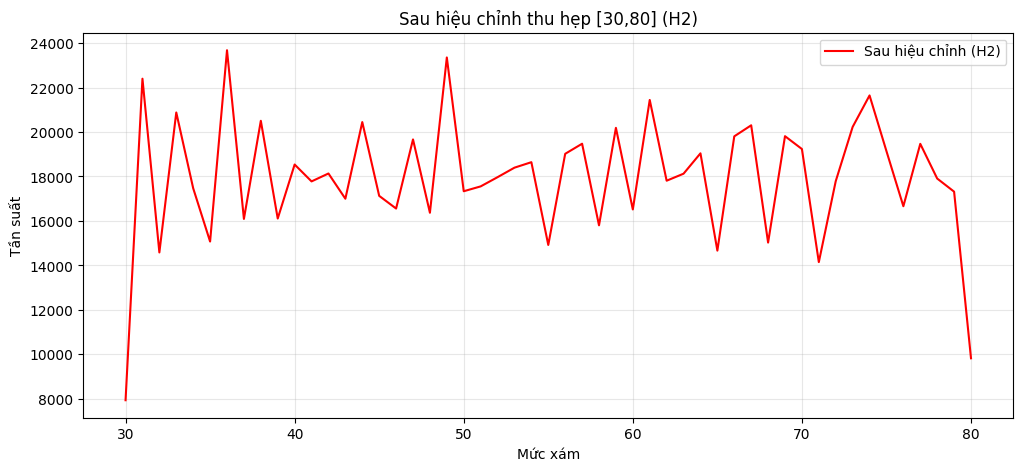

In [70]:
histogramUpdate = {}
for row in matrixUpdate:
    for val in row:
        histogramUpdate[val] = histogramUpdate.get(val, 0) + 1

plt.figure(figsize=(12,5))
plt.plot(sorted(histogramUpdate.keys()), [histogramUpdate[k] for k in sorted(histogramUpdate)], label="Sau hiệu chỉnh (H2)", color='red')
plt.title("Sau hiệu chỉnh thu hẹp [30,80] (H2)")
plt.xlabel("Mức xám")
plt.ylabel("Tần suất")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Phần 2 — Convolutional Filtering (I1, I2, I3)

**Mục tiêu:** áp dụng 3 kernel khác nhau lên ảnh I (xám):
- Kernel 3×3, padding=1 → I1
- Kernel 5×5, padding=2 → I2
- Kernel 7×7, padding=3, stride=2 → I3 (dịch chuyển ngang & dọc: stride áp dụng cho cả 2 chiều)

- Giữ padding/stride chính xác bằng công thức:
    out_h = (h - k + 2*padding)//stride + 1


In [71]:
def convolution(matrix, kernel, padding=0, stride=1):
    h = len(matrix)     
    w = len(matrix[0])    
    k = len(kernel)       
    
# Tạo ma trận “đệm” (padding)
    padded = []
    for i in range(h + 2*padding):
        row = []
        for j in range(w + 2*padding):
            row.append(0)  
        padded.append(row)

# Sao chép ảnh gốc vào vùng giữa của padded    
    for i in range(h):
        for j in range(w):
            padded[i + padding][j + padding] = matrix[i][j]

# Tính kích thước ảnh đầu ra   
    out_h = (h - k + 2*padding )//stride + 1
    out_w = (w - k + 2*padding )//stride + 1
    output = []
    
# Thực hiện tích chập    
    for i in range(out_h):
        row = []
        for j in range(out_w):
            total = 0
            for ki in range(k):
                for kj in range(k):
                    total += padded[i*stride + ki][j*stride + kj] * kernel[ki][kj]
            row.append(total)
        output.append(row)
    
    return output

## Dùng phép tích chập (convolutional operator) để lọc ảnh I với các thông số sau:

·        Kernel 3x3, padding = 1 (I1)

·        Kernel 5x5, padding = 2 (I2)

·        Kernel 7x7, padding = 3 và stride = 2 (Dịch chuyển ngang và dọc) (I3)

In [72]:
kernel3 = [
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
]

kernel5 = [
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]
]



kernel7 = [
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1,  0,  0,  0, -1, -1],
    [-1, -1,  0, 32,  0, -1, -1],
    [-1, -1,  0,  0,  0, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1, -1, -1]
]



In [73]:
I1 = convolution(matrix, kernel3, padding=1, stride=1)
I2 = convolution(matrix, kernel5, padding=2, stride=1)
I3 = convolution(matrix, kernel7, padding=3, stride=2)

Anh I1:


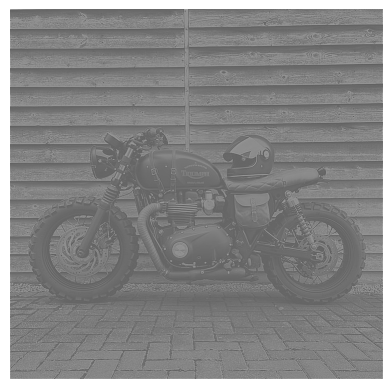

Anh I2:


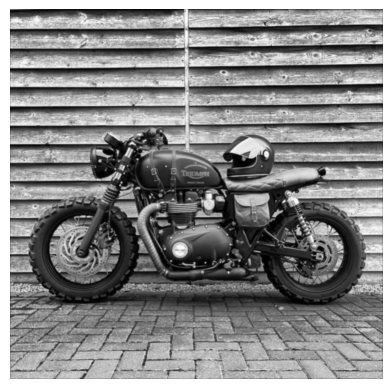

Anh I3:


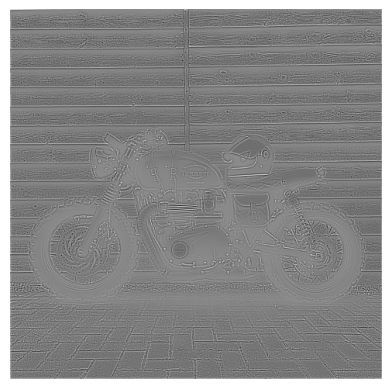

In [74]:
print("Anh I1:")
plt.imshow(I1, cmap='gray')
plt.axis('off')
plt.show()

print("Anh I2:")
plt.imshow(I2, cmap='gray')
plt.axis('off')
plt.show()

print("Anh I3:")
plt.imshow(I3, cmap='gray')
plt.axis('off')
plt.show()

## Bộ lọc trung vị (Median Filter) 
- Tìm ảnh I4 bằng cách lọc trung vị ảnh I3 với lân cận neighbors 3x3

- Tìm ảnh I5 là bằng cách lọc trong bị ảnh I1 với lân cận lân cận neighbors 5x5.

In [75]:
def filter(matrix, kernel_size):
    h, w = len(matrix), len(matrix[0])
    pad = kernel_size // 2
    
    padded = np.zeros((h + 2*pad, w + 2*pad))
    padded[pad:pad+h, pad:pad+w] = matrix
    
    output = np.zeros((h, w))
    
    for i in range(h):
        for j in range(w):
            neighbors = []
            for ki in range(kernel_size):
                for kj in range(kernel_size):
                    neighbors.append(padded[i+ki, j+kj])
            output[i,j] = np.median(neighbors)
    return output

In [76]:
I4 = filter(I3, kernel_size=3)
I5 = filter(I1, kernel_size=5)

Anh I4:


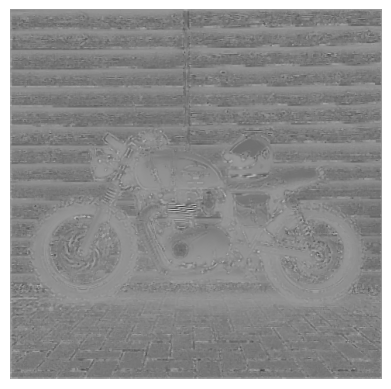

Anh I5:


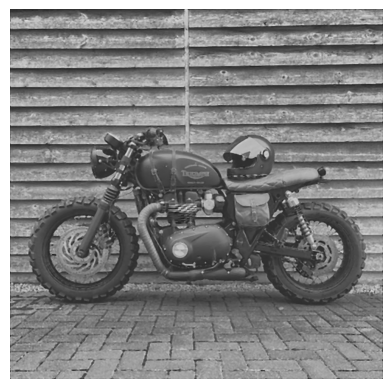

In [77]:
print("Anh I4:")
plt.imshow(I4, cmap='gray')
plt.axis('off')
plt.show()

print("Anh I5:")
plt.imshow(I5, cmap='gray')
plt.axis('off')
plt.show()

### Xây dựng ảnh I6 bằng cách lấy ngưỡng: Nếu I4(x,y)>I5(x,y) thì I6(x,y)=0, ngược lại I6(x,y)= I5(x,y). Trường hợp hai ảnh không bằng nhau về kích thước thì biến đổi (thêm padding) để các ảnh có cùng kích thước trước khi tính toán.

In [78]:
def threshold_images(I4, I5):
    h1, w1 = len(I4), len(I4[0])
    h2, w2 = len(I5), len(I5[0])
    
    h = max(h1, h2)
    w = max(w1, w2)

# Dùng để đệm ảnh nhỏ hơn cho bằng kích thước lớn hơn.    
    def pad_to_size(img, target_h, target_w):
        h_img = len(img)
        w_img = len(img[0])
        
        padded = []
        for i in range(target_h):
            row = []
            for j in range(target_w):
                row.append(0)
            padded.append(row)
        
        padding_h = (target_h - h_img) // 2
        padding_w = (target_w - w_img) // 2
        
        for i in range(h_img):
            for j in range(w_img):
                padded[i + padding_h][j + padding_w] = img[i][j]

        return padded
    
    # Chuẩn hóa hai ảnh về cùng kích thước
    I4_pad = pad_to_size(I4, h, w)
    I5_pad = pad_to_size(I5, h, w)

    # Lấy ngưỡng giữa hai ảnh    
    I6 = []
    for i in range(h):
        row = []
        for j in range(w):
            if I4_pad[i][j] > I5_pad[i][j]:
                row.append(0)
            else:
                row.append(I5_pad[i][j])
        I6.append(row)
    return I6


Anh I6:


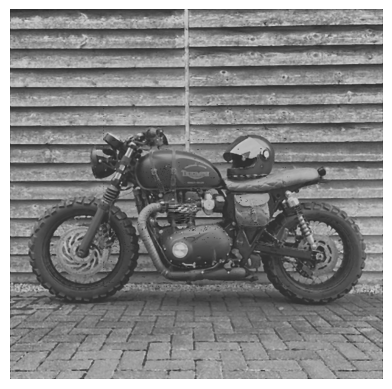

In [79]:
I6 = threshold_images(I4, I5)

print("Anh I6:")
plt.imshow(I6, cmap='gray')
plt.axis('off')
plt.show()

## KẾT LUẬN

Qua quá trình thực hiện bài tập lớn về **xử lý ảnh số**, nhóm đã hoàn thành toàn bộ các yêu cầu từ việc tiền xử lý, biến đổi ảnh đến các bước trích xuất thông tin cơ bản thông qua các kỹ thuật xử lý ảnh truyền thống. Cụ thể như sau:



### 1. Chuyển đổi ảnh màu sang ảnh xám
- Ảnh gốc RGB được chuyển về dạng ảnh xám nhằm giảm bớt dữ liệu và tập trung vào thông tin độ sáng (*luminance*).  
- Việc này giúp đơn giản hóa các phép xử lý tiếp theo như lọc, cân bằng histogram và ngưỡng ảnh.


### 2. Phân tích và cân bằng Histogram
- Biểu đồ histogram ban đầu thể hiện phân bố mức xám không đồng đều, nhiều điểm ảnh tập trung ở một dải giá trị hẹp → ảnh có **độ tương phản thấp**.  
- Sau khi **cân bằng histogram**, ảnh có độ tương phản cao hơn, phân bố mức xám trải đều hơn trên toàn dải động.  
- Bước **hiệu chỉnh thu hẹp dải giá trị** về khoảng *(30, 80)* giúp điều chỉnh độ sáng/tối phù hợp hơn với mục tiêu hiển thị hoặc xử lý tiếp theo.

### 3. Lọc ảnh bằng phép tích chập (Convolution)
Các phép lọc được thực hiện với các **kernel khác nhau (3×3, 5×5, 7×7)** cùng các thông số *padding* và *stride* khác nhau, cho thấy sự thay đổi rõ rệt về mức độ làm mượt và chi tiết của ảnh:
- Kernel **3×3**: giữ lại chi tiết tốt, nhưng nhiễu còn khá rõ.  
- Kernel **5×5**: ảnh được làm mượt hơn, độ chi tiết giảm nhẹ.  
- Kernel **7×7, stride=2**: làm mượt mạnh, giảm nhiễu hiệu quả nhưng mất nhiều chi tiết; đồng thời giảm kích thước ảnh (*downsampling*).

Việc thay đổi kích thước và bước dịch chuyển stride giúp mô phỏng một phần cơ chế hoạt động của các tầng tích chập trong **mạng CNN**, thể hiện ứng dụng thực tế của toán tử tích chập trong học sâu.


### 4. Lọc trung vị (Median Filter)
- Phép lọc trung vị với lân cận 3×3 hoặc 5×5 giúp **loại bỏ nhiễu xung (salt & pepper noise)** hiệu quả mà vẫn giữ được các biên (*edge*) tương đối rõ.  
- Đây là một kỹ thuật lọc phi tuyến tính phổ biến trong tiền xử lý ảnh, đặc biệt hữu ích trước các bước phân đoạn (segmentation) hoặc nhận dạng đối tượng.



### 5. Ngưỡng hóa (Thresholding)
- Ảnh sau khi lọc được so sánh theo điều kiện:

  \[

    
    I6(x, y) = 

  \begin{cases} 
      0, & \text{nếu } I4(x, y) > I5(x, y) \\
      I5(x, y), & \text{ngược lại}
  \end{cases}
  \]

- Bước này giúp phân tách rõ ràng vùng sáng – tối hoặc vật thể – nền, là cơ sở cho các bài toán trích chọn biên và nhận dạng sau này.  
- Trong trường hợp kích thước ảnh không đồng nhất, việc thêm **padding** trước khi xử lý giúp đảm bảo phép toán được thực hiện chính xác.



### 6. Tổng kết và đánh giá
- Các bước xử lý ảnh đã thể hiện rõ **tác động của từng phép toán** đến kết quả hình ảnh:  
  từ việc **cải thiện độ tương phản** (histogram) đến **làm mượt và khử nhiễu** (convolution, median filter) và **phân tách đối tượng** (thresholding).  
- Quá trình chuẩn hóa, padding và đồng bộ kích thước ảnh đảm bảo tính chính xác và ổn định của toàn bộ pipeline xử lý.  
- Kết quả cho thấy **các phương pháp xử lý ảnh cổ điển vẫn có vai trò quan trọng**, là nền tảng cho các kỹ thuật học sâu hiện đại trong thị giác máy tính.



### 7. Hướng phát triển
- Áp dụng các phép lọc khác như **Gaussian, Sobel, Laplacian** để trích xuất đặc trưng và phát hiện biên mạnh mẽ hơn.  
- So sánh kết quả với các kỹ thuật hiện đại như **Adaptive Histogram Equalization (CLAHE)** hoặc **Bilateral Filter**.  
- Tích hợp pipeline này làm **bước tiền xử lý dữ liệu đầu vào cho mô hình CNN**, nhằm cải thiện hiệu quả huấn luyện và độ chính xác của mô hình.


**Tóm lại**, bài thực hành này giúp củng cố kiến thức về các phép toán cơ bản trong xử lý ảnh, đồng thời rèn luyện khả năng lập trình, phân tích và trực quan hóa dữ liệu ảnh trong môi trường Python/Jupyter Notebook.  
Kết quả đạt được phản ánh sự hiểu biết sâu sắc về mối quan hệ giữa lý thuyết và thực hành trong lĩnh vực **Image Processing**.
